# Decoy-gated text→logic hallucination control — interactive demo

**Artifact:** *Decoy-gated text-to-logic hallucination control on the 24-doc legal/news/regulatory anchor.*

This pipeline translates short professional documents into `(head, relation, tail)` facts that
feed a running logic engine, then **gates** which extracted facts are admitted using a
**label-free decoy-competition (knockoff+) FDR controller** — and reports the resulting
reduction in hallucinated facts vs the raw LLM, with **human-auditable trace-graphs**.

### What this demo runs (CPU-only, no API key)

The full pipeline (`method.py`) makes thousands of paid LLM calls to *extract* and *score* facts.
Those scores are expensive but deterministic once produced, so this demo loads the **cached
per-fact scores** (the signed-max knockoff statistic `W_i`, gold label, and hallucination flag
for every extracted fact in the **legal / CUAD-crisp** slice) and **re-runs the deterministic
analysis core verbatim**:

1. **`fdr_stats.py`** — the knockoff+ operative threshold `T(α)` (Barber–Candès 2015, eq 1.9)
   and the document-block bootstrap, copied unchanged.
2. **`kb_engine.py`** — the pure-Python backward-chaining meta-interpreter that produces the
   auditable proof trace-graphs, copied unchanged.

The demo reproduces the published *legal* hallucination grid **exactly** from the cached scores
— admissions, realized FDR, the gate's self-reported `decoy_fdr_hat`, and bootstrap-CI
hallucination rates — and rebuilds a real 2-hop proof with per-leaf certificates. No LLM calls.


In [1]:
# --- Install dependencies (Colab + local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / scipy / matplotlib are pre-installed on Colab. On Colab, DO NOT reinstall them
# (it corrupts the pre-loaded C extensions). Install locally at Colab's exact versions.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors method.py + fdr_stats.py + kb_engine.py) ---
from __future__ import annotations
import json, os, math, hashlib, html, itertools
from collections import defaultdict
from typing import Callable, Sequence

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


In [3]:
# --- Data loading (GitHub URL with local fallback, for Colab compatibility) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-3/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
data = load_data()

meta = data["metadata"]
examples = data["datasets"][0]["examples"]
print("Method :", meta["method_name"])
print("Subset :", meta["demo_subset"]["genre"],
      "| gold:", meta["demo_subset"]["gold_quality"],
      "| n_reals:", meta["demo_subset"]["n_reals"])
print("Examples loaded:", len(examples))
print("Published legal grid cells available for comparison:",
      len(meta["hallucination_grid_legal"]))


Method : Label-free decoy-competition (knockoff+) FDR gate for LLM text->logic fact admission, with auditable trace-graphs
Subset : legal | gold: crisp (CUAD) | n_reals: 71
Examples loaded: 71
Published legal grid cells available for comparison: 10


## Configuration

All tunable parameters live here. The analysis is pure CPU (no LLM calls), so every knob below
is set to its **true value from the original run** *except* `B_BOOT` — the number of
document-block bootstrap resamples — which is the only runtime-sensitive parameter and starts
small for a fast demo.

- `ALPHA_GRID` — the target-FDR levels the knockoff+ gate is certified at (original full grid).
- `ELICITATIONS` — `logprob` (single-token softmax P(Yes)) and `portable` (K=5 self-consistency).
- `B_BOOT` — bootstrap resamples for the hallucination-rate CIs. **Original: 2000.**
- `SEED`, `R_ENTRAP` — reproducibility seed and entrapment ratio (verbatim from `method.py`).


In [5]:
# --- Config (start B_BOOT small; original run used 2000) ---
ALPHA_GRID   = [0.05, 0.10, 0.20, 0.30, 0.50]   # knockoff+ k-floors {20,10,5,4,2}
ELICITATIONS = ["logprob", "portable"]          # both label-free elicitations
B_BOOT       = 2000                             # bootstrap resamples (ORIGINAL=2000)
SEED         = 20240617                          # method.py SEED
R_ENTRAP     = 1                                 # paired entrapment ratio

# Keys in each cached example row, per elicitation:
#   W_i (signed-max knockoff statistic), and the published gate admission flags.
ELIC_KEYS = {
    "logprob":  {"w": "metadata_w_cf_lp", "admit": "predict_admit_lp_"},
    "portable": {"w": "metadata_w_cf_pt", "admit": "predict_admit_pt_"},
}
ALPHA_TAG = {0.05: "a05", 0.10: "a10", 0.20: "a20", 0.30: "a30", 0.50: "a50"}
print("ALPHA_GRID =", ALPHA_GRID, "| B_BOOT =", B_BOOT, "| ELICITATIONS =", ELICITATIONS)


ALPHA_GRID = [0.05, 0.1, 0.2, 0.3, 0.5] | B_BOOT = 2000 | ELICITATIONS = ['logprob', 'portable']


## Step 1 — The FDR gate primitives (`fdr_stats.py`, verbatim)

These functions are copied **unchanged** from the artifact's `fdr_stats.py`. They are pure (no
I/O, no API). The heart of the method is `knockoff_plus_threshold`: the Barber–Candès knockoff+
operative cutoff `T(α)` that controls the *exact* false-discovery rate of admitted facts using
only each fact's signed-max statistic `W_i` — **no labels**.


In [6]:
# ===== fdr_stats.py (verbatim core) ============================================
def W_signed_max(z_real: float, z_decoy: float) -> float:
    """Signed-max statistic: magnitude = max(|real|,|decoy|), sign + iff real beats decoy."""
    mag = max(z_real, z_decoy)
    s = z_real - z_decoy
    sign = 0.0 if s == 0 else math.copysign(1.0, s)
    return mag * sign


def knockoff_plus_threshold(W: Sequence[float], alpha: float):
    """knockoff+ operative cutoff T(alpha) (Barber-Candes 2015, eq 1.9):

        T = min{ t in |W| : (1 + #{W_i <= -t}) / max(1, #{W_i >= t}) <= alpha }

    Returns (T, n_admitted, realized_ratio). If no feasible cutoff exists, admit nothing.
    """
    Wa = np.asarray([w for w in W], dtype=float)
    if Wa.size == 0:
        return math.inf, 0, 1.0
    cands = sorted({abs(w) for w in Wa if w != 0.0})
    best = (math.inf, 0, 1.0)
    for t in cands:
        if t <= 0:
            continue
        pos = int(np.sum(Wa >= t))
        neg = int(np.sum(Wa <= -t))
        ratio = (1 + neg) / max(1, pos)
        if ratio <= alpha:
            return float(t), pos, float(ratio)
    return best


def k_floor(alpha: float) -> int:
    """Minimum admissions needed to certify FDR<=alpha (FDR floor 1/k => k>=ceil(1/alpha))."""
    return int(math.ceil(1.0 / alpha))


def doc_block_bootstrap(doc_units: list, stat_fn: Callable[[list], float],
                        B: int = 2000, seed: int = 0, ci: float = 0.95) -> dict:
    """Resample whole documents with replacement B times; recompute stat_fn on the
    pooled resample. Returns point estimate, percentile CI, and bootstrap SE."""
    n = len(doc_units)
    point = stat_fn(doc_units)
    if n == 0:
        return {"point": float("nan"), "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": 0}
    rng = np.random.default_rng(seed)
    reps = np.empty(B)
    idx_all = np.arange(n)
    for b in range(B):
        idx = rng.choice(idx_all, size=n, replace=True)
        resample = [doc_units[i] for i in idx]
        reps[b] = stat_fn(resample)
    reps = reps[~np.isnan(reps)]
    if reps.size == 0:
        return {"point": float(point) if point == point else float("nan"),
                "ci_low": float("nan"), "ci_high": float("nan"),
                "se": float("nan"), "B": B, "n_docs": n}
    lo = float(np.percentile(reps, 100 * (1 - ci) / 2))
    hi = float(np.percentile(reps, 100 * (1 - (1 - ci) / 2)))
    return {"point": float(point) if point == point else float(np.mean(reps)),
            "ci_low": lo, "ci_high": hi, "se": float(np.std(reps, ddof=1)),
            "B": int(reps.size), "n_docs": n}


def benjamini_hochberg(pvals: Sequence[float], q: float = 0.05) -> list:
    """BH step-up. Returns list aligned to input order with adjusted p and reject flag."""
    p = np.asarray(pvals, float)
    m = p.size
    if m == 0:
        return []
    order = np.argsort(p, kind="mergesort")
    ranked = p[order]
    adj = np.empty(m)
    prev = 1.0
    for i in range(m - 1, -1, -1):
        val = ranked[i] * m / (i + 1)
        prev = min(prev, val)
        adj[i] = min(prev, 1.0)
    adj_orig = np.empty(m)
    adj_orig[order] = adj
    return [{"raw_p": float(p[i]), "bh_adj_p": float(adj_orig[i]),
             "reject": bool(adj_orig[i] <= q)} for i in range(m)]

print("fdr_stats core loaded:", [W_signed_max, knockoff_plus_threshold, k_floor,
                                 doc_block_bootstrap, benjamini_hochberg].__len__(), "functions")


fdr_stats core loaded: 5 functions


## Step 2 — The proof engine (`kb_engine.py`, verbatim)

Copied **unchanged** from `kb_engine.py`. This is a classic vanilla meta-interpreter for
backward chaining over admitted facts plus hand-authored genre bridge rules. Every leaf carries
a *certificate* (provenance + decoy `W_i,T,α` + entrapment `FDP_hat,r`) so each derived
conclusion is fully auditable. `proof_to_graph` / `graph_to_dot` export the trace-graph.


In [7]:
# ===== kb_engine.py (verbatim core) ============================================
class Var:
    __slots__ = ("name",)
    def __init__(self, name): self.name = name
    def __eq__(self, other): return isinstance(other, Var) and other.name == self.name
    def __hash__(self): return hash(("Var", self.name))
    def __repr__(self): return f"?{self.name}"

def V(name): return Var(name)
def is_var(x): return isinstance(x, Var)

def unify(pat, val, subst):
    """Unify a (possibly variable-bearing) arg tuple `pat` with ground tuple `val`."""
    s = dict(subst)
    for p, v in zip(pat, val):
        if is_var(p):
            if p in s:
                if s[p] != v:
                    return None
            else:
                s[p] = v
        elif p != v:
            return None
    return s

def subst_args(args, subst):
    return tuple(subst.get(a, a) if is_var(a) else a for a in args)

class KB:
    """Admitted facts + bridge rules + a backward-chaining solver with proof capture."""
    def __init__(self):
        self.facts = {}
        self.by_pred = {}
        self.rules = []

    def add_fact(self, pred, args, cert):
        key = (pred, tuple(args))
        if key not in self.facts:
            self.facts[key] = cert
            self.by_pred.setdefault(pred, []).append(tuple(args))

    def add_rule(self, name, head_pred, head_args, body):
        self.rules.append({"name": name, "head_pred": head_pred,
                           "head_args": tuple(head_args), "body": list(body)})

    @staticmethod
    def _rename(atom_args, tag):
        return tuple(Var(f"{a.name}_{tag}") if is_var(a) else a for a in atom_args)

    def _solve_atom(self, pred, args, subst, depth):
        g_args = subst_args(args, subst)
        for fact_args in self.by_pred.get(pred, []):
            s2 = unify(g_args, fact_args, subst)
            if s2 is not None:
                cert = self.facts[(pred, fact_args)]
                yield s2, {"type": "leaf", "atom": [pred, list(fact_args)], "cert": cert}
        if depth <= 0:
            return
        for ri, rule in enumerate(self.rules):
            if rule["head_pred"] != pred:
                continue
            tag = f"{depth}_{ri}"
            head = self._rename(rule["head_args"], tag)
            s_head = unify(head, g_args, subst)
            if s_head is None:
                continue
            body = [(p, self._rename(a, tag)) for (p, a) in rule["body"]]
            for sb, child_proofs in self._solve_body(body, s_head, depth - 1):
                head_ground = subst_args(head, sb)
                if any(is_var(a) for a in head_ground):
                    continue
                yield sb, {"type": "derived", "atom": [pred, list(head_ground)],
                           "rule": rule["name"], "children": child_proofs}

    def _solve_body(self, body, subst, depth):
        if not body:
            yield subst, []
            return
        first, rest = body[0], body[1:]
        for s2, proof in self._solve_atom(first[0], first[1], subst, depth):
            for s3, proofs in self._solve_body(rest, s2, depth):
                yield s3, [proof] + proofs

    def run_rule(self, rule, max_depth=4):
        body = list(rule["body"])
        for sb, child_proofs in self._solve_body(body, {}, max_depth):
            head_ground = subst_args(rule["head_args"], sb)
            if any(is_var(a) for a in head_ground):
                continue
            yield {"type": "derived", "atom": [rule["head_pred"], list(head_ground)],
                   "rule": rule["name"], "children": child_proofs}

    def derive_all(self, max_depth=4):
        seen, out = set(), []
        for rule in self.rules:
            for proof in self.run_rule(rule, max_depth):
                key = (proof["atom"][0], tuple(proof["atom"][1]))
                if key in seen:
                    continue
                seen.add(key)
                out.append(proof)
        return out


def iter_leaves(proof):
    if proof["type"] == "leaf":
        yield proof
    else:
        for c in proof.get("children", []):
            yield from iter_leaves(c)


def proof_to_graph(proof):
    """Flatten a proof tree into {nodes:[{id,label,kind,cert?}], edges:[{src,dst,rule}]}."""
    nodes, edges = [], []
    counter = itertools.count()
    def atom_str(atom):
        pred, args = atom[0], atom[1]
        return f"{pred}({', '.join(map(str, args))})"
    def walk(node):
        nid = next(counter)
        if node["type"] == "leaf":
            nodes.append({"id": nid, "label": atom_str(node["atom"]),
                          "kind": "leaf", "cert": node.get("cert")})
        else:
            nodes.append({"id": nid, "label": atom_str(node["atom"]),
                          "kind": "derived", "rule": node.get("rule")})
            for c in node.get("children", []):
                cid = walk(c)
                edges.append({"src": nid, "dst": cid, "rule": node.get("rule")})
        return nid
    walk(proof)
    return {"nodes": nodes, "edges": edges}


def graph_to_dot(graph, title=""):
    """Render a flattened proof graph to Graphviz DOT (gate status colour-coded)."""
    lines = ["digraph proof {", '  rankdir=TB;',
             '  node [style=filled, fontname="Helvetica", fontsize=10];']
    if title:
        lines.append(f'  labelloc="t"; label="{html.escape(title)}";')
    for n in graph["nodes"]:
        label = html.escape(n["label"])
        if n["kind"] == "derived":
            color, extra = "lightblue", f'\\nrule: {html.escape(str(n.get("rule")))}'
            tooltip = "derived conclusion"
        else:
            cert = n.get("cert") or {}
            hv = cert.get("hallucination_verdict", "?")
            color = "lightsalmon" if hv == "HALLUCINATED" else "palegreen"
            dc = cert.get("decoy_certificate") or {}
            ec = cert.get("entrapment_certificate") or {}
            extra = (f'\\nW={dc.get("W_i")} T={dc.get("T")} a={dc.get("alpha")}'
                     f'\\nFDP_hat={ec.get("FDP_hat")} r={ec.get("r")}')
            tooltip = html.escape(str(cert.get("provenance", ""))[:200] or "leaf fact")
        lines.append(f'  n{n["id"]} [label="{label}{extra}", fillcolor="{color}", '
                     f'tooltip="{tooltip}"];')
    for e in graph["edges"]:
        lines.append(f'  n{e["src"]} -> n{e["dst"]} [label="{html.escape(str(e.get("rule") or ""))}", '
                     f'fontsize=8];')
    lines.append("}")
    return "\n".join(lines)

print("kb_engine core loaded: KB / unify / proof_to_graph / graph_to_dot")


kb_engine core loaded: KB / unify / proof_to_graph / graph_to_dot


## Step 3 — Load the cached per-fact scores

Each example row is one extracted real `(head, relation, tail)` fact from a legal document,
carrying the **precomputed** signed-max knockoff statistic `W_i` for both elicitations, the
gold label (`TRUE/FALSE/UNDECIDABLE`), and the adjudicated hallucination flag `hall_adj`.

We parse the rows into the same lightweight structure `method.py` builds for its
`gate_and_hall_grid` — one record per real fact. (The `W_i` values were produced by the
expensive LLM scoring stage; here we just read them back.)


In [8]:
# Parse cached rows -> per-real records (the input to the gate, exactly as in method.py).
reals = []
for e in examples:
    inp = json.loads(e["input"])
    reals.append({
        "doc_id": e["metadata_doc_id"],
        "h": inp["head"], "r": inp["relation"], "t": inp["tail"],
        "label": e["output"],                        # TRUE / FALSE / UNDECIDABLE (crisp gold)
        "hall_adj": bool(e["metadata_hall_adj"]),     # adjudicated hallucination flag
        "prov": e["metadata_provenance_quote"],       # provenance quote (for leaf certificates)
        "w_logprob": e["metadata_w_cf_lp"],           # signed-max W_i (logprob elicitation)
        "w_portable": e["metadata_w_cf_pt"],          # signed-max W_i (portable elicitation)
        "predict": e,                                 # keep the row for validation vs published flags
    })

n_docs = len({r["doc_id"] for r in reals})
from collections import Counter
lab = Counter(r["label"] for r in reals)
print(f"{len(reals)} legal real facts across {n_docs} documents")
print("label counts:", dict(lab))
print("example W_i (logprob) for first 6 facts:",
      [round(r["w_logprob"], 3) for r in reals[:6]])


71 legal real facts across 6 documents
label counts: {'TRUE': 16, 'UNDECIDABLE': 53, 'FALSE': 2}
example W_i (logprob) for first 6 facts: [0.833, -1.0, 0.917, 0.792, 0.875, 0.846]


## Step 4 — Re-run the decoy-gate grid (mirrors `method.py: gate_and_hall_grid`)

For each `(elicitation, α)` we:
1. compute the knockoff+ threshold `T(α)` over the facts' `W_i` values,
2. **admit** facts with `W_i ≥ T`,
3. report the gate's self-estimated FDR (`decoy_fdr_hat = ratio`), the realized FDR vs crisp gold,
   and the **hallucinated-fact rate** for the gate vs the raw LLM with document-block bootstrap CIs.

This is the same loop as `gate_and_hall_grid`, restricted to the legal genre and driven by the
cached `W_i`. The raw baseline admits *all* facts (the LLM's unfiltered output).


In [9]:
def _rate(units, key):
    # mean of a boolean field over the flattened per-document units (verbatim from method.py)
    flat = [f for u in units for f in u]
    if not flat:
        return float("nan")
    return float(np.mean([1.0 if f[key] else 0.0 for f in flat]))

docs_in = sorted({r["doc_id"] for r in reals})

grid = []
for elic in ELICITATIONS:
    wkey = "w_logprob" if elic == "logprob" else "w_portable"
    Wr = [r[wkey] for r in reals]
    for alpha in ALPHA_GRID:
        T, n_pos, ratio = knockoff_plus_threshold(Wr, alpha)
        admit = [] if math.isinf(T) else [r for r in reals if r[wkey] >= T]
        N_T = len(admit)
        realized = (sum(1 for r in admit if r["label"] == "FALSE") / N_T) if N_T else 0.0
        kf = k_floor(alpha)
        # document-block bootstrap CIs on the hallucinated-fact rate
        raw_units  = [[r for r in reals if r["doc_id"] == did] for did in docs_in]
        gate_units = [[r for r in admit if r["doc_id"] == did] for did in docs_in]
        raw_ci  = doc_block_bootstrap(raw_units,  lambda u: _rate(u, "hall_adj"), B=B_BOOT, seed=SEED)
        gate_ci = doc_block_bootstrap(gate_units, lambda u: _rate(u, "hall_adj"), B=B_BOOT, seed=SEED)
        regime = ("anti_conservative_expected" if elic == "logprob"
                  else ("certified" if N_T >= kf else "uncertified(n<1/alpha)"))
        grid.append({
            "genre": "legal", "elicitation": elic, "alpha": alpha,
            "n_reals": len(reals), "n_admitted": N_T, "k_floor": kf,
            "certified": bool(N_T >= kf),
            "threshold": (None if math.isinf(T) else round(T, 6)),
            "decoy_fdr_hat": round(ratio, 6),
            "realized_fdr": round(realized, 6),
            "gate_hall_rate": (round(gate_ci["point"], 6) if not math.isnan(gate_ci["point"]) else None),
            "gate_hall_ci": [gate_ci["ci_low"], gate_ci["ci_high"]],
            "raw_hall_rate": (round(raw_ci["point"], 6) if not math.isnan(raw_ci["point"]) else None),
            "raw_hall_ci": [raw_ci["ci_low"], raw_ci["ci_high"]],
            "regime_tag": regime,
            "ci_separation_gate_below_raw": bool(
                not math.isnan(gate_ci["ci_high"]) and not math.isnan(raw_ci["ci_low"])
                and gate_ci["ci_high"] < raw_ci["ci_low"]),
        })

print(f"Recomputed {len(grid)} grid cells "
      f"({len(ELICITATIONS)} elicitations x {len(ALPHA_GRID)} alphas)")
for c in grid:
    print(f"  {c['elicitation']:8s} a={c['alpha']:.2f}  T={str(c['threshold']):>8}  "
          f"admit={c['n_admitted']:3d}  decoy_fdr_hat={c['decoy_fdr_hat']:.3f}  "
          f"realized_fdr={c['realized_fdr']:.3f}  certified={c['certified']}")


Recomputed 10 grid cells (2 elicitations x 5 alphas)
  logprob  a=0.05  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  logprob  a=0.10  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  logprob  a=0.20  T= 0.22973  admit= 61  decoy_fdr_hat=0.180  realized_fdr=0.016  certified=True
  logprob  a=0.30  T= 0.22973  admit= 61  decoy_fdr_hat=0.180  realized_fdr=0.016  certified=True
  logprob  a=0.50  T= 0.22973  admit= 61  decoy_fdr_hat=0.180  realized_fdr=0.016  certified=True
  portable a=0.05  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  portable a=0.10  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  portable a=0.20  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  portable a=0.30  T=    None  admit=  0  decoy_fdr_hat=1.000  realized_fdr=0.000  certified=False
  portable a=0.50  T=0.129032  admit= 50  decoy_fdr_hat=0.4

## Step 5 — Validate: recomputed gate == published results

Two independent checks that the demo faithfully reproduces the original pipeline from cached scores:

1. **Per-fact admissions** — our recomputed `W_i ≥ T(α)` decisions must match the published
   `predict_admit_*` flags stored in every row, for all `(elicitation, α)`.
2. **Grid cells** — our recomputed `n_admitted`, `decoy_fdr_hat`, `realized_fdr`, and the
   bootstrap hallucination rates must match the published legal `hallucination_grid` cells.


In [10]:
# --- Check 1: per-fact admissions match published predict_admit flags ---
mismatch = 0
for elic in ELICITATIONS:
    wkey = "w_logprob" if elic == "logprob" else "w_portable"
    admit_key = ELIC_KEYS[elic]["admit"]
    Wr = [r[wkey] for r in reals]
    for alpha in ALPHA_GRID:
        T, _, _ = knockoff_plus_threshold(Wr, alpha)
        for r in reals:
            recomputed = (not math.isinf(T)) and (r[wkey] >= T)
            published = (r["predict"][admit_key + ALPHA_TAG[alpha]] == "yes")
            mismatch += int(recomputed != published)
print(f"Check 1 — per-fact admission mismatches vs published flags: {mismatch}  "
      f"({'PASS' if mismatch == 0 else 'FAIL'})")

# --- Check 2: grid cells match the published legal hallucination_grid ---
pub = {(c["genre"], c["elicitation"], c["alpha"]): c for c in meta["hallucination_grid_legal"]}
print("\nCheck 2 — recomputed grid vs published grid:")
print(f"  {'elic':8s} {'a':>4s} | {'admit':>11s} | {'decoy_fdr_hat':>22s} | {'gate_hall':>20s}")
all_ok = True
for c in grid:
    p = pub[(c["genre"], c["elicitation"], c["alpha"])]
    adm_ok = (c["n_admitted"] == p["n_admitted"])
    fdr_ok = abs(c["decoy_fdr_hat"] - p["decoy_fdr_hat"]) < 1e-4
    gh_pub = p["gate_hall_rate"]
    gh_ok = (c["gate_hall_rate"] is None and gh_pub is None) or (
        c["gate_hall_rate"] is not None and gh_pub is not None
        and abs(c["gate_hall_rate"] - gh_pub) < 1e-4)
    all_ok = all_ok and adm_ok and fdr_ok and gh_ok
    print(f"  {c['elicitation']:8s} {c['alpha']:>4.2f} | "
          f"{c['n_admitted']:>4d} vs {p['n_admitted']:<4d} "
          f"{'OK' if adm_ok else 'XX'} | "
          f"{c['decoy_fdr_hat']:>9.4f} vs {p['decoy_fdr_hat']:<9.4f} "
          f"{'OK' if fdr_ok else 'XX'} | "
          f"{str(c['gate_hall_rate']):>8} vs {str(gh_pub):<8} {'OK' if gh_ok else 'XX'}")
print(f"\nGrid reproduction: {'PASS — exact match' if all_ok else 'FAIL'}")


Check 1 — per-fact admission mismatches vs published flags: 0  (PASS)

Check 2 — recomputed grid vs published grid:
  elic        a |       admit |          decoy_fdr_hat |            gate_hall
  logprob  0.05 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  logprob  0.10 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  logprob  0.20 |   61 vs 61   OK |    0.1803 vs 0.1803    OK | 0.016393 vs 0.016393 OK
  logprob  0.30 |   61 vs 61   OK |    0.1803 vs 0.1803    OK | 0.016393 vs 0.016393 OK
  logprob  0.50 |   61 vs 61   OK |    0.1803 vs 0.1803    OK | 0.016393 vs 0.016393 OK
  portable 0.05 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  portable 0.10 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  portable 0.20 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  portable 0.30 |    0 vs 0    OK |    1.0000 vs 1.0000    OK |     None vs None     OK
  portable 0.5

## Step 6 — Auditable proof trace-graph (`kb_engine` live)

The pipeline's deliverable is a **human-auditable reasoning trace**. We rebuild a real 2-hop
legal derivation end-to-end: load every extracted fact for one document, attach each leaf's
**certificate** (provenance + decoy `W_i,T,α` + entrapment `FDP_hat,r`), add the hand-authored
legal bridge rules (verbatim from `method.py: BRIDGE_RULES["legal"]`), and run the backward-chaining
engine. This mirrors `method.py: build_kb` exactly. The headline elicitation is **portable** and
the gate cell is the certified `α=0.5` cell, so the reproduced certificates match the published trace.

```
party_bound_effective(A, P, D) :- has_party(A, P), effective_date(A, D).
titled_dated(A, T, D)          :- has_title(A, T), agreement_date(A, D).
```


In [11]:
# Legal bridge rules, verbatim from method.py BRIDGE_RULES["legal"]
BRIDGE_RULES_LEGAL = [
    ("party_bound_effective", "party_bound_effective", (V("A"), V("P"), V("D")),
     [("has_party", (V("A"), V("P"))), ("effective_date", (V("A"), V("D")))]),
    ("titled_dated", "titled_dated", (V("A"), V("T"), V("D")),
     [("has_title", (V("A"), V("T"))), ("agreement_date", (V("A"), V("D")))]),
]

# Headline elicitation + its certified gate cell (carries threshold T and alpha for the certs).
DEMO_DOC      = meta["trace_graph_legal_example"]["doc_id"]    # legal_cuad_00
HEADLINE_ELIC = "portable"
WKEY          = "w_portable"
gate_cell = next(c for c in reversed([g for g in grid if g["elicitation"] == HEADLINE_ELIC])
                 if c["certified"])
# entrapment FDP_hat comes from the full entrapment pool (published grid; not in the mini subset)
pub_cell = next(c for c in meta["hallucination_grid_legal"]
                if c["elicitation"] == HEADLINE_ELIC and c["alpha"] == gate_cell["alpha"])
fdp_hat = pub_cell["entrapment"]["FDP_hat"]

def build_kb(doc_reals, gate_cell, fdp_hat):
    # verbatim logic from method.py build_kb: each extracted fact -> a leaf with a certificate.
    kb = KB()
    for f in doc_reals:
        w = f[WKEY]
        cert = {"provenance": f["prov"],
                "provenance_char_span": None,
                "hallucination_verdict": "HALLUCINATED" if f["hall_adj"] else "ENTAILED",
                "decoy_certificate": {"W_i": round(w, 4),
                                      "T": gate_cell["threshold"], "alpha": gate_cell["alpha"]},
                "entrapment_certificate": {"FDP_hat": fdp_hat, "r": R_ENTRAP}}
        kb.add_fact(f["r"], (f["h"], f["t"]), cert)
    for spec in BRIDGE_RULES_LEGAL:
        kb.add_rule(*spec)
    return kb

doc_reals = [r for r in reals if r["doc_id"] == DEMO_DOC]
kb = build_kb(doc_reals, gate_cell, fdp_hat)
derived = kb.derive_all(max_depth=4)

print(f"Document {DEMO_DOC}: {len(doc_reals)} extracted facts -> "
      f"{len(derived)} multi-hop conclusion(s) (gate α={gate_cell['alpha']}, T={gate_cell['threshold']}):\n")
for p in derived:
    print("  CONCLUSION:", f"{p['atom'][0]}({', '.join(p['atom'][1])})", "[rule:", p["rule"] + "]")
    for lf in iter_leaves(p):
        cert = lf["cert"]; dc = cert.get("decoy_certificate", {})
        print(f"     <- {lf['atom'][0]}({', '.join(lf['atom'][1])})")
        print(f"        verdict={cert.get('hallucination_verdict')}  "
              f"W_i={dc.get('W_i')} T={dc.get('T')} alpha={dc.get('alpha')}")
        print(f"        provenance: \"{str(cert.get('provenance',''))[:80]}...\"")

# Export the first derivation's trace-graph as Graphviz DOT
graph = proof_to_graph(derived[0])
dot = graph_to_dot(graph, title=f"{DEMO_DOC} [legal] {derived[0]['rule']}")
print("\n----- trace-graph (Graphviz DOT) -----")
print(dot)


Document legal_cuad_00: 5 extracted facts -> 2 multi-hop conclusion(s) (gate α=0.5, T=0.129032):

  CONCLUSION: party_bound_effective(Premium Managed Hosting Agreement, AstroNutrition.com, March 1, 2005) [rule: party_bound_effective]
     <- has_party(Premium Managed Hosting Agreement, AstroNutrition.com)
        verdict=ENTAILED  W_i=0.8421 T=0.129032 alpha=0.5
        provenance: "This is a managed hosting agreement between AstroNutrition.com and deep systems...."
     <- effective_date(Premium Managed Hosting Agreement, March 1, 2005)
        verdict=ENTAILED  W_i=0.7895 T=0.129032 alpha=0.5
        provenance: "The effective term is 12 months beginning March 1, 2005..."
  CONCLUSION: party_bound_effective(Premium Managed Hosting Agreement, deep systems, March 1, 2005) [rule: party_bound_effective]
     <- has_party(Premium Managed Hosting Agreement, deep systems)
        verdict=ENTAILED  W_i=0.9474 T=0.129032 alpha=0.5
        provenance: "This is a managed hosting agreement betwe

## Results — visualization

A compact view of the headline analysis the artifact reports for the legal slice:

- **(left)** distribution of the signed-max knockoff statistic `W_i` with the knockoff+
  thresholds `T(α)` overlaid — facts to the right of a line are admitted at that α;
- **(centre)** the gate's self-reported FDR (`decoy_fdr_hat`) vs the realized FDR vs crisp gold;
- **(right)** hallucinated-fact rate of the gate vs the raw LLM with 95% bootstrap CIs.


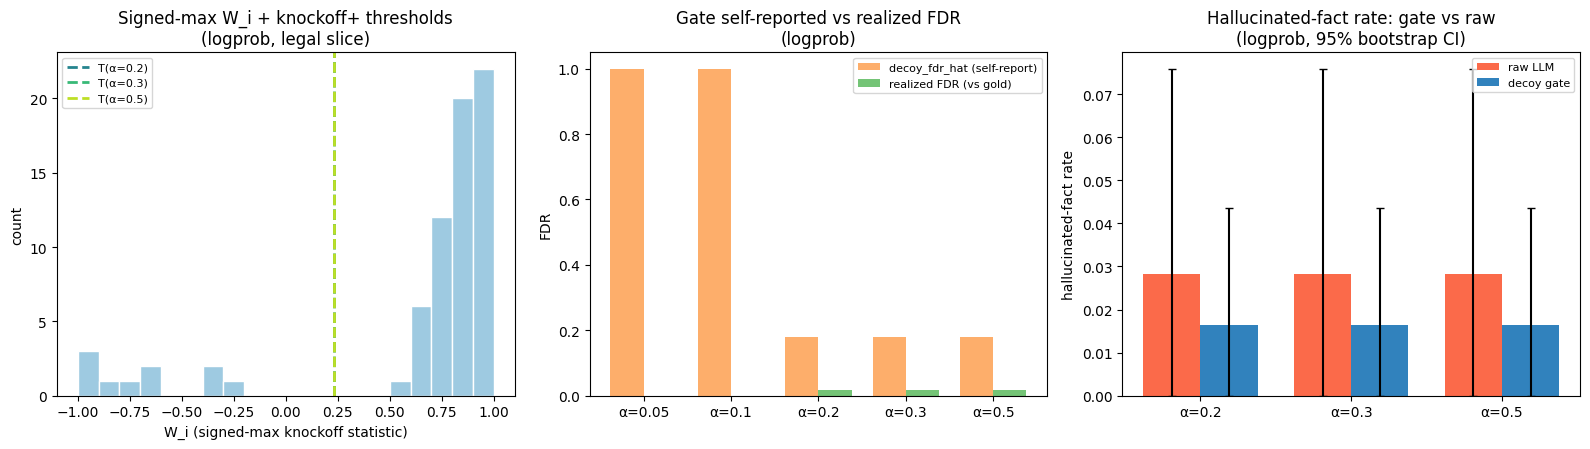


=== Legal-slice headline (recomputed from cached scores) ===
elic      alpha  admit  cert decoy_fdr_hat  realized  raw_hall gate_hall
logprob    0.05      0 False        1.0000    0.0000  0.028169      None
logprob    0.10      0 False        1.0000    0.0000  0.028169      None
logprob    0.20     61  True        0.1803    0.0164  0.028169  0.016393
logprob    0.30     61  True        0.1803    0.0164  0.028169  0.016393
logprob    0.50     61  True        0.1803    0.0164  0.028169  0.016393
portable   0.05      0 False        1.0000    0.0000  0.028169      None
portable   0.10      0 False        1.0000    0.0000  0.028169      None
portable   0.20      0 False        1.0000    0.0000  0.028169      None
portable   0.30      0 False        1.0000    0.0000  0.028169      None
portable   0.50     50  True        0.4400    0.0200  0.028169      0.02

Full-run context (24-doc anchor): Decoy-gating reduces the hallucinated-fact rate vs raw LLM in 0 of the grid cells with CI separation

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
elic_show = "logprob"   # the headline elicitation for the W-distribution panel
wkey = "w_logprob" if elic_show == "logprob" else "w_portable"

# --- Panel 1: W_i distribution with knockoff+ thresholds ---
ax = axes[0]
Wvals = [r[wkey] for r in reals]
ax.hist(Wvals, bins=20, color="#9ecae1", edgecolor="white")
cmap = plt.cm.viridis(np.linspace(0, 0.9, len(ALPHA_GRID)))
for alpha, col in zip(ALPHA_GRID, cmap):
    T, _, _ = knockoff_plus_threshold(Wvals, alpha)
    if not math.isinf(T):
        ax.axvline(T, color=col, ls="--", lw=2, label=f"T(α={alpha})")
ax.set_title(f"Signed-max W_i + knockoff+ thresholds\n({elic_show}, legal slice)")
ax.set_xlabel("W_i (signed-max knockoff statistic)"); ax.set_ylabel("count")
ax.legend(fontsize=8)

# --- Panel 2: decoy_fdr_hat vs realized FDR (logprob) ---
ax = axes[1]
cells = [c for c in grid if c["elicitation"] == elic_show]
x = np.arange(len(cells)); w = 0.38
ax.bar(x - w/2, [c["decoy_fdr_hat"] for c in cells], w, label="decoy_fdr_hat (self-report)", color="#fdae6b")
ax.bar(x + w/2, [c["realized_fdr"] for c in cells], w, label="realized FDR (vs gold)", color="#74c476")
ax.set_xticks(x); ax.set_xticklabels([f"α={c['alpha']}" for c in cells])
ax.set_title(f"Gate self-reported vs realized FDR\n({elic_show})")
ax.set_ylabel("FDR"); ax.legend(fontsize=8)

# --- Panel 3: gate vs raw hallucinated-fact rate with bootstrap CIs ---
ax = axes[2]
cert_cells = [c for c in cells if c["gate_hall_rate"] is not None]
x = np.arange(len(cert_cells)); w = 0.38
def _err(c, key, ci):
    pt = c[key]; lo, hi = c[ci]
    return [[max(0.0, pt - lo)], [max(0.0, hi - pt)]]
for i, c in enumerate(cert_cells):
    ax.bar(i - w/2, c["raw_hall_rate"], w, color="#fb6a4a",
           yerr=_err(c, "raw_hall_rate", "raw_hall_ci"), capsize=3,
           label="raw LLM" if i == 0 else None)
    ax.bar(i + w/2, c["gate_hall_rate"], w, color="#3182bd",
           yerr=_err(c, "gate_hall_rate", "gate_hall_ci"), capsize=3,
           label="decoy gate" if i == 0 else None)
ax.set_xticks(x); ax.set_xticklabels([f"α={c['alpha']}" for c in cert_cells])
ax.set_title(f"Hallucinated-fact rate: gate vs raw\n({elic_show}, 95% bootstrap CI)")
ax.set_ylabel("hallucinated-fact rate"); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

# --- Headline summary table ---
print("\n=== Legal-slice headline (recomputed from cached scores) ===")
print(f"{'elic':9s} {'alpha':>5s} {'admit':>6s} {'cert':>5s} "
      f"{'decoy_fdr_hat':>13s} {'realized':>9s} {'raw_hall':>9s} {'gate_hall':>9s}")
for c in grid:
    print(f"{c['elicitation']:9s} {c['alpha']:>5.2f} {c['n_admitted']:>6d} "
          f"{str(c['certified']):>5s} {c['decoy_fdr_hat']:>13.4f} {c['realized_fdr']:>9.4f} "
          f"{str(c['raw_hall_rate']):>9} {str(c['gate_hall_rate']):>9}")
print("\nFull-run context (24-doc anchor):", meta["headline_finding"][:200], "...")
